# Road Accident Analysis in India: Patterns, Causes and High-Risk Factors

**Part 1 : Data Collection, Data Cleaning, Missing Values and EDA**

Data source : Ministry of Road Transport & Highways (MoRTH) reports, data.gov.in and WHO (for country comparison)

Libraries used : pandas, numpy, matplotlib

## Step 1 : Importing the libraries

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil      # for copying files into folders

import warnings
warnings.filterwarnings('ignore')   # to hide the yellow warning messages

## Step 2 : Loading all the datasets



In [193]:
# speed related accidents (2008 - 2016)
speed_injured = pd.read_csv(r"Road Accident Analysis/Accidents_Due_To_Exceeding_Lawful_Speed_Persons_Injured_2008-2016.csv")
speed_killed = pd.read_csv(r"Road Accident Analysis/Accidents_Due_To_Exceeding_Lawful_Speed_Persons_Killed_2008-2016.csv")
# deaths per 1 lakh people - India vs other countries (2019)
world_deaths = pd.read_csv(r"Road Accident Analysis/Deaths from road accidents for every 100,000 people (2019) - Data For India.csv")
# 2018 data - road features and age group
road_features = pd.read_csv(r"Road Accident Analysis/Road-Accidents-2018-Annexure-23.csv")
age_gender = pd.read_csv(r"Road Accident Analysis/Road-Accidents-2018-Table-2.9.csv")

# 2024 data
city_violation = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-cities-fatalities-traffic-violation.csv")
road_user = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-fatality-road-user.csv")
safety_device = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-safety-device.csv")
state_killed = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-states-fatalities.csv")
state_accidents = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-states-road-accidents.csv")
collision = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-type-of-collision.csv")
license_type = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-type-of-license.csv")
violation = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-type-of-violation.csv")
victim_vehicle = pd.read_csv(r"Road Accident Analysis/road-accidents-2024-victims-crime-vehicle.csv")

# yearly data
annual = pd.read_csv(r"Road Accident Analysis/road-accidents-annual-2020-2024.csv")
density = pd.read_csv(r"Road Accident Analysis/road-accidents-registrations-density-2014-24.csv")

print("All files loaded successfully")

All files loaded successfully


## Step 3 : First look at the data

In [194]:
# putting all dataframes in a dictionary so i can check all of them at once
all_data = {
    'speed_injured': speed_injured,
    'speed_killed': speed_killed,
    'world_deaths': world_deaths,
    'road_features': road_features,
    'age_gender': age_gender,
    'city_violation': city_violation,
    'road_user': road_user,
    'safety_device': safety_device,
    'state_killed': state_killed,
    'state_accidents': state_accidents,
    'collision': collision,
    'license_type': license_type,
    'violation': violation,
    'victim_vehicle': victim_vehicle,
    'annual': annual,
    'density': density
}

for name in all_data:
    df = all_data[name]
    print(name, "-> rows:", df.shape[0], ", columns:", df.shape[1], ", null values:", df.isnull().sum().sum())

speed_injured -> rows: 37 , columns: 10 , null values: 13
speed_killed -> rows: 37 , columns: 10 , null values: 11
world_deaths -> rows: 14 , columns: 2 , null values: 0
road_features -> rows: 37 , columns: 44 , null values: 2
age_gender -> rows: 16 , columns: 11 , null values: 32
city_violation -> rows: 51 , columns: 9 , null values: 52
road_user -> rows: 19 , columns: 4 , null values: 9
safety_device -> rows: 5 , columns: 5 , null values: 0
state_killed -> rows: 39 , columns: 13 , null values: 33
state_accidents -> rows: 39 , columns: 14 , null values: 37
collision -> rows: 19 , columns: 10 , null values: 27
license_type -> rows: 9 , columns: 7 , null values: 4
violation -> rows: 13 , columns: 10 , null values: 18
victim_vehicle -> rows: 20 , columns: 11 , null values: 29
annual -> rows: 5 , columns: 7 , null values: 0
density -> rows: 15 , columns: 8 , null values: 31


In [195]:
# checking few datasets one by one
state_accidents.head()

,Sl No,State,2020 Accidents,2021 Accidents,2022 Accidents,2023 Accidents,2024 Accidents,Change from 2023 to 2024,% change from 2023 to 2024,2020 Ranking,2021 Ranking,2022 Ranking,2023 Ranking,2024 Ranking
0,1,Andhra Pradesh,"19,509","21,556","21,249","19,949","19,557",-392,-2.0,7.0,7.0,9.0,9.0,9.0
1,2,Arunachal Pradesh,134,283,227,287,277,-10,-3.5,32.0,28.0,31.0,29.0,27.0
2,3,Assam,"6,595","7,411","7,023","7,421","7,848",427,5.8,16.0,16.0,16.0,16.0,16.0
3,4,Bihar,"8,639","9,553","10,801","11,014","11,610",596,5.4,15.0,15.0,14.0,14.0,14.0
4,5,Chhattisgarh,"11,656","12,375","13,279","13,468","14,857","1,389",10.3,11.0,11.0,12.0,12.0,11.0


In [196]:
state_accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sl No                       38 non-null     str    
 1   State                       37 non-null     str    
 2   2020 Accidents              36 non-null     str    
 3   2021 Accidents              37 non-null     str    
 4   2022 Accidents              37 non-null     str    
 5   2023 Accidents              37 non-null     str    
 6   2024 Accidents              37 non-null     str    
 7   Change from 2023 to 2024    37 non-null     str    
 8   % change from 2023 to 2024  37 non-null     float64
 9   2020 Ranking                35 non-null     float64
 10  2021 Ranking                35 non-null     float64
 11  2022 Ranking                36 non-null     float64
 12  2023 Ranking                36 non-null     float64
 13  2024 Ranking                34 non-null     floa

In [197]:
violation

,Category,2023-Accidents,2023-Killed,2023-injured,2024-Accidents,2024-Killed,2024-injured,%Change-Accidents,%Change-killed,%Change-Injured
0,Over-speeding,"3,28,727","1,17,682","3,20,416","3,45,024","1,24,522","3,34,045",4.96,5.81,4.25
1,% share of total,68.4,68.07,69.23,70.74,70.28,70.86,NaN,NaN,NaN
2,Drunken driving/consumption of alcohol & drug,"9,143","3,674","8,421","8,270","3,204","8,046",-9.55,-12.79,-4.45
3,% share of total,1.9,2.13,1.82,1.7,1.81,1.71,NaN,NaN,NaN
4,Driving on wrong side/Lane indiscipline,"25,242","9,432","24,435","22,530","8,327","22,467",-10.74,-11.72,-8.05
5,% share of total,5.25,5.46,5.28,4.62,4.7,4.77,NaN,NaN,NaN
6,Jumping red light,"2,440",818,"2,157","1,559",528,"1,648",-36.11,-35.45,-23.60
7,% share of total,0.51,0.47,0.47,0.32,0.3,0.35,NaN,NaN,NaN
8,Use of mobile phone,"7,122","2,884","6,445","4,935","2,002","4,831",-30.71,-30.58,-25.04
9,% share of total,1.48,1.67,1.39,1.01,1.13,1.02,NaN,NaN,NaN


### Problems I found in the raw data

1. Numbers are stored as **text** with commas (Indian format like `3,72,181`), so we cannot do maths on them.
2. Many files have extra **"% share"** rows in between the real data rows.
3. Some files have **Total / All India** rows and **footnote** rows at the bottom.
4. Some files have **empty columns** (like `Unnamed: 8`).
5. Some values are written as **NA** (missing).
6. Road length has values like `6498 (P)` where P means provisional.

So we need to clean every file before analysis.

## Step 4 : Data Cleaning and Handling Missing Values

I am writing one small function to remove commas and convert a column into numbers,
because this same problem is there in almost every file.

In [198]:
def make_numeric(df, columns):
    for col in columns:
        df[col] = df[col].astype(str).str.replace(',', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')   # if something is not a number it becomes NaN
    return df

### 4.1 Speed data (2008 - 2016)

In [199]:
print("Null values in speed_killed:")
print(speed_killed.isnull().sum())
print()
print(speed_killed[speed_killed.isnull().any(axis=1)])

Null values in speed_killed:
States/UTs    0
2008          1
2009          1
2010          1
2011          2
2012          3
2013          2
2014          1
2015          0
2016          0
dtype: int64

     States/UTs  2008  2009  2010   2011   2012  2013    2014     2015  2016
18     Nagaland  25.0   0.0   0.0    0.0    NaN   0.0    12.0     2.00     6
24    Telangana   NaN   NaN   NaN    NaN    NaN   NaN  2156.0  4962.88  3541
30   Chandigarh  20.0  88.0  17.0    NaN   24.0   5.0    62.0    61.00   142
33        Delhi   0.0   0.0   0.0  365.0  329.0   NaN     NaN   640.00   318
34  Lakshadweep   0.0   0.0   0.0    0.0    NaN   0.0     0.0     0.00     0


**How I am handling the missing values here:**
- Telangana was formed only in 2014, so 2008 - 2013 values are missing for it. These are filled with **0** because the state did not exist.
- For the other states, missing values are filled with the **average of that state** across the other years.

In [200]:
years_before_telangana = ['2008', '2009', '2010', '2011', '2012', '2013']
year_cols = ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']

for df in [speed_killed, speed_injured]:
    # telangana -> 0 before 2014
    df.loc[df['States/UTs'] == 'Telangana', years_before_telangana] = 0

    # other states -> fill with the state's own average
    for i in df.index:
        state_avg = df.loc[i, year_cols].mean()
        df.loc[i, year_cols] = df.loc[i, year_cols].fillna(state_avg)

    # values are number of persons so they should be whole numbers
    df[year_cols] = df[year_cols].round(0).astype(int)

print("Nulls left in speed_killed :", speed_killed.isnull().sum().sum())
print("Nulls left in speed_injured:", speed_injured.isnull().sum().sum())

Nulls left in speed_killed : 0
Nulls left in speed_injured: 0


In [201]:
# the last row is All India total, keeping it separately
speed_killed_india = speed_killed[speed_killed['States/UTs'] == 'All India']
speed_injured_india = speed_injured[speed_injured['States/UTs'] == 'All India']

speed_killed = speed_killed[speed_killed['States/UTs'] != 'All India']
speed_injured = speed_injured[speed_injured['States/UTs'] != 'All India']

print(speed_killed.shape, speed_injured.shape)
speed_killed.head()

(36, 10) (36, 10)


,States/UTs,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Andhra Pradesh,7471,6407,5211,4560,6201,4448,4190,4101,5564
1,Arunachal Pradesh,32,35,42,72,15,27,11,12,41
2,Assam,843,1244,1400,1233,1430,1341,1465,1281,1094
3,Bihar,1008,1551,1452,1748,1266,1205,746,1366,1509
4,Chhattisgarh,1347,1474,1382,1431,1186,1307,1750,1709,1735


### 4.2 World deaths data

In [202]:
world_deaths.columns = ['Country', 'Deaths_per_100k']
world_deaths['Deaths_per_100k'] = world_deaths['Deaths_per_100k'].round(1)
print("Null values:", world_deaths.isnull().sum().sum())
world_deaths

Null values: 0


,Country,Deaths_per_100k
0,Bangladesh,15.3
1,Brazil,16.0
2,China,17.4
3,Indonesia,11.3
4,India,15.6
5,Kenya,28.3
6,Sri Lanka,19.7
7,Nigeria,20.7
8,Pakistan,13.0
9,Russian Federation,12.0


### 4.3 Road features data (2018)

In [203]:
# removing the Total row and the S.No column
road_features = road_features[road_features['S.No'] != 'Total']
road_features = road_features.drop(columns=['S.No'])

# removing the rank columns (we dont need rank, and the nulls were only in these columns)
rank_cols = []
for col in road_features.columns:
    if 'Rank' in col:
        rank_cols.append(col)
road_features = road_features.drop(columns=rank_cols)

# straight road columns have different names from others, so renaming them
road_features = road_features.rename(columns={
    'Straight Road - Number of Accidents - Number': 'Straight Road - Number of Accidents',
    'Straight Road - Persons Killed - Number': 'Straight Road - Persons Killed'
})

print("Shape:", road_features.shape)
print("Null values:", road_features.isnull().sum().sum())

Shape: (36, 41)
Null values: 0


In [204]:
# making a small summary table : total accidents and deaths for each road feature
features = ['Straight Road', 'Curved Road', 'Bridge', 'Culvert', 'Pot Holes',
            'Steep Grade', 'Ongoing Road Works/Under Construction', 'Others']

feature_accidents = []
feature_killed = []
for f in features:
    feature_accidents.append(road_features[f + ' - Number of Accidents'].sum())
    feature_killed.append(road_features[f + ' - Persons Killed'].sum())

feature_summary = pd.DataFrame({
    'Road Feature': features,
    'Accidents': feature_accidents,
    'Killed': feature_killed
})
feature_summary['Road Feature'] = feature_summary['Road Feature'].replace(
    'Ongoing Road Works/Under Construction', 'Road Works')
feature_summary

,Road Feature,Accidents,Killed
0,Straight Road,306855,96831
1,Curved Road,64100,19996
2,Bridge,16125,5693
3,Culvert,9183,3192
4,Pot Holes,4869,2015
5,Steep Grade,6305,2433
6,Road Works,11539,4288
7,Others,48068,16969


### 4.4 Age group and gender data (2018)

In [205]:
# removing the '% Share' rows, the Total row and the share row
age_gender = age_gender[~age_gender['Age-Group'].str.contains('Share')]
age_gender = age_gender[age_gender['Age-Group'] != 'Total']

# % change columns are not needed (they had all the NA values)
age_gender = age_gender[['Age-Group', '2016 - Male', '2016 - Female', '2017 - Male',
                         '2017 - Female', '2018 - Male', '2018 - Female']]
age_gender = age_gender.reset_index(drop=True)

print("Null values:", age_gender.isnull().sum().sum())
age_gender

Null values: 0


,Age-Group,2016 - Male,2016 - Female,2017 - Male,2017 - Female,2018 - Male,2018 - Female
0,Less than 18,8347.0,2275.0,7443.0,1965.0,7817.0,2160.0
1,18-25,27417.0,4358.0,30148.0,4096.0,28835.0,3942.0
2,25-35,32609.0,5467.0,34728.0,4821.0,34943.0,5017.0
3,35-45,28564.0,4994.0,28538.0,4250.0,28210.0,4462.0
4,45-60,18592.0,3582.0,19235.0,3227.0,19343.0,3455.0
5,Above 60,6964.0,1850.0,7696.0,1688.0,7343.0,1732.0
6,Age not known,4960.0,806.0,67.0,11.0,3653.0,505.0


### 4.5 City wise violation data (2024)

In [206]:
# last column is completely empty
city_violation = city_violation.drop(columns=['Unnamed: 8'])

# last row has no city name (it is the total row)
city_violation = city_violation.dropna(subset=['City'])

print("Shape:", city_violation.shape)
print("Null values:", city_violation.isnull().sum().sum())
city_violation.head()

Shape: (50, 8)
Null values: 0


,City,Over-speeding,Drunk Driving,Wrong Side,Jumping Red Light,Mobile Phone,Others,Total
0,Agra,269,33,83,31,11,159,586
1,Ahmedabad,396,6,8,0,0,0,410
2,Allahabad (Prayagraj),327,0,152,0,0,68,547
3,Amritsar,46,1,2,0,0,29,78
4,Asansol Durgapur,129,0,1,0,0,175,305


### 4.6 Road user data (2024)

In [207]:
road_user = road_user[~road_user['Road-user category'].str.contains('share')]
road_user = road_user[road_user['Road-user category'] != 'Total']
road_user = make_numeric(road_user, ['Persons killed 2023', 'Persons killed 2024'])

# the 'Others' name is very long so making it short
road_user['Road-user category'] = road_user['Road-user category'].replace({
    'Other Non- Motor Vehicles (including e-rickshaw)': 'Other Non-Motor',
    'Others (other motor vehicles, animals drawn vehicle, cycle rickshaws, hand carts, & other persons)': 'Others'
})
road_user = road_user.reset_index(drop=True)
print("Null values:", road_user.isnull().sum().sum())
road_user

Null values: 0


,Road-user category,Persons killed 2023,Persons killed 2024,% Change 2024 over 2023
0,Pedestrian,35221,36526,3.7
1,Bicycles,4560,4161,-8.8
2,Two-wheelers,77539,81780,5.5
3,Auto-Rickshaws,6308,5659,-10.3
4,"Cars, Taxis, Vans & LMVs",21496,21988,2.3
5,Trucks/Lorries,10066,9687,-3.8
6,Buses,3956,3855,-2.6
7,Other Non-Motor,2006,1629,-18.8
8,Others,11738,11890,1.3


### 4.7 Safety device data (2024)

In [208]:
safety_device = safety_device[~safety_device['Category'].str.contains('Share')]
safety_device = safety_device[safety_device['Category'] != 'Total']
safety_device = make_numeric(safety_device, ['No Helmet - Killed', 'No Helmet - Injured',
                                             'No Seat belt - killed', 'No seat belt - injured'])
safety_device = safety_device.reset_index(drop=True)
safety_device

,Category,No Helmet - Killed,No Helmet - Injured,No Seat belt - killed,No seat belt - injured
0,Drivers,39470,64520,7489,15695
1,Passenger,14652,39012,6977,21458


### 4.8 State wise fatalities and accidents (2020 - 2024)

In [209]:
print(state_killed.tail(4))

                         Sl No       State 2020 Killed 2021 Killed  \
35                          36  Puducherry         145         140   
36                       Total   All India    1,38,383    1,53,972   
37                         NaN         NaN         NaN         NaN   
38  # includes Ladakh for 2020         NaN         NaN         NaN   

   2022 Killed 2023 Killed 2024 Killed  % change from 2023 to 2024  \
35         181         149         218                       46.31   
36    1,68,491    1,72,890    1,77,175                        2.48   
37         NaN         NaN         NaN                         NaN   
38         NaN         NaN         NaN                         NaN   

    2020 Ranking  2021 Ranking  2022 Ranking  2023 Ranking  2024 Ranking  
35          25.0          27.0          25.0          26.0          25.0  
36           NaN           NaN           NaN           NaN           NaN  
37           NaN           NaN           NaN           NaN           NaN 

- The last rows are the All India total, an empty row and a footnote, so I am removing them.
- The Ranking columns are dropped (I will calculate ranks myself if needed).
- **Ladakh 2020 is NA** because in 2020 Ladakh was counted inside J&K (the footnote says this). So it is filled with **0**.

In [210]:
for df_name in ['state_killed', 'state_accidents']:
    df = all_data[df_name]
    df = df.dropna(subset=['State'])           # removes empty row and footnote row
    df = df[df['State'] != 'All India']        # removes total row
    df = df.drop(columns=['Sl No'])

    # dropping ranking columns
    df = df.drop(columns=['2020 Ranking', '2021 Ranking', '2022 Ranking', '2023 Ranking', '2024 Ranking'])

    df['State'] = df['State'].replace('J & K #', 'Jammu & Kashmir')
    all_data[df_name] = df

state_killed = all_data['state_killed']
state_accidents = all_data['state_accidents']

killed_cols = ['2020 Killed', '2021 Killed', '2022 Killed', '2023 Killed', '2024 Killed']
acc_cols = ['2020 Accidents', '2021 Accidents', '2022 Accidents', '2023 Accidents', '2024 Accidents']

state_killed = make_numeric(state_killed, killed_cols)
state_accidents = make_numeric(state_accidents, acc_cols + ['Change from 2023 to 2024'])

# Ladakh 2020 -> 0
state_killed = state_killed.fillna(0)
state_accidents = state_accidents.fillna(0)

# converting to int because number of people/accidents cant be in decimal
state_killed[killed_cols] = state_killed[killed_cols].astype(int)
state_accidents[acc_cols] = state_accidents[acc_cols].astype(int)

state_killed = state_killed.reset_index(drop=True)
state_accidents = state_accidents.reset_index(drop=True)

print("state_killed    -> shape:", state_killed.shape, " nulls:", state_killed.isnull().sum().sum())
print("state_accidents -> shape:", state_accidents.shape, " nulls:", state_accidents.isnull().sum().sum())
state_accidents.head()

state_killed    -> shape: (36, 7)  nulls: 0
state_accidents -> shape: (36, 8)  nulls: 0


,State,2020 Accidents,2021 Accidents,2022 Accidents,2023 Accidents,2024 Accidents,Change from 2023 to 2024,% change from 2023 to 2024
0,Andhra Pradesh,19509,21556,21249,19949,19557,-392,-2.0
1,Arunachal Pradesh,134,283,227,287,277,-10,-3.5
2,Assam,6595,7411,7023,7421,7848,427,5.8
3,Bihar,8639,9553,10801,11014,11610,596,5.4
4,Chhattisgarh,11656,12375,13279,13468,14857,1389,10.3


### 4.9 Type of collision, violation and license (2024)

In [211]:
# collision
collision = collision[~collision['Type of collision'].str.contains('share')]
collision = collision[collision['Type of collision'] != 'Total']
collision = make_numeric(collision, ['2023-Accidents', '2023-Killed', '2023-injured',
                                     '2024-Accidents', '2024-Killed', '2024-injured'])
collision = collision.reset_index(drop=True)

# violation
violation = violation[~violation['Category'].str.contains('share')]
violation = violation[violation['Category'] != 'All India']
violation = make_numeric(violation, ['2023-Accidents', '2023-Killed', '2023-injured',
                                     '2024-Accidents', '2024-Killed', '2024-injured'])
violation['Category'] = violation['Category'].replace({
    'Drunken driving/consumption of alcohol & drug': 'Drunk Driving',
    'Driving on wrong side/Lane indiscipline': 'Wrong Side Driving'
})
violation = violation.reset_index(drop=True)

# license
license_type = license_type[~license_type['Type of license'].str.contains('share')]
license_type = license_type[license_type['Type of license'] != 'Total']
license_type = make_numeric(license_type, ['2020', '2021', '2022', '2023', '2024'])
license_type = license_type.reset_index(drop=True)

print("collision nulls   :", collision.isnull().sum().sum())
print("violation nulls   :", violation.isnull().sum().sum())
print("license nulls     :", license_type.isnull().sum().sum())
violation

collision nulls   : 0
violation nulls   : 0
license nulls     : 0


,Category,2023-Accidents,2023-Killed,2023-injured,2024-Accidents,2024-Killed,2024-injured,%Change-Accidents,%Change-killed,%Change-Injured
0,Over-speeding,328727,117682,320416,345024,124522,334045,4.96,5.81,4.25
1,Drunk Driving,9143,3674,8421,8270,3204,8046,-9.55,-12.79,-4.45
2,Wrong Side Driving,25242,9432,24435,22530,8327,22467,-10.74,-11.72,-8.05
3,Jumping red light,2440,818,2157,1559,528,1648,-36.11,-35.45,-23.60
4,Use of mobile phone,7122,2884,6445,4935,2002,4831,-30.71,-30.58,-25.04
5,Others,107909,38400,100951,105389,38592,100404,-2.34,0.50,-0.54


### 4.10 Victim vehicle vs Crime vehicle (2024)

In [212]:
victim_vehicle = victim_vehicle.rename(columns={victim_vehicle.columns[0]: 'Victim'})
victim_vehicle = victim_vehicle.drop(columns=['<-- Crime Vehicle'])   # empty column

victim_vehicle = victim_vehicle[~victim_vehicle['Victim'].str.contains('Share')]
victim_vehicle = victim_vehicle[victim_vehicle['Victim'] != 'Total']
victim_vehicle = victim_vehicle[victim_vehicle['Victim'] != 'Victim Vehicle(Column above)']

vehicle_cols = list(victim_vehicle.columns[1:])
victim_vehicle = make_numeric(victim_vehicle, vehicle_cols)

# short names for the chart
short_names = ['Pedestrian', 'Bicycle', 'Two Wheeler', 'Auto', 'Car/Taxi/LMV',
               'Truck', 'Bus', 'Non-Motor', 'Others']
victim_vehicle['Victim'] = short_names
victim_vehicle.columns = ['Victim', 'Bicycle', 'Two Wheeler', 'Auto', 'Car/Taxi/LMV',
                          'Truck', 'Bus', 'Non-Motor', 'Others', 'Total']
victim_vehicle = victim_vehicle.reset_index(drop=True)

print("Null values:", victim_vehicle.isnull().sum().sum())
victim_vehicle

Null values: 0


,Victim,Bicycle,Two Wheeler,Auto,Car/Taxi/LMV,Truck,Bus,Non-Motor,Others,Total
0,Pedestrian,76.0,10378,1256,9302,5165,2257,235,7857,36526
1,Bicycle,43.0,1137,248,1039,718,333,80,563,4161
2,Two Wheeler,247.0,30561,2620,18682,14017,4485,495,10673,81780
3,Auto,39.0,602,1196,1461,1151,508,94,608,5659
4,Car/Taxi/LMV,147.0,3344,645,8705,5240,1570,212,2125,21988
5,Truck,85.0,1846,293,1563,3717,666,117,1400,9687
6,Bus,59.0,740,147,564,792,958,86,509,3855
7,Non-Motor,33.0,298,157,374,251,171,138,207,1629
8,Others,99.0,3632,406,2072,1311,526,199,3645,11890


### 4.11 Annual data (2020 - 2024)

In [213]:
annual.columns = ['Year', 'Accidents', 'Accidents % Change', 'Fatalities',
                  'Fatalities % Change', 'Injured', 'Injured % Change']
annual = make_numeric(annual, ['Accidents', 'Fatalities', 'Injured'])
print("Null values:", annual.isnull().sum().sum())
annual

Null values: 0


,Year,Accidents,Accidents % Change,Fatalities,Fatalities % Change,Injured,Injured % Change
0,2020,372181,-18.6,138383,-13.0,346747,-22.8
1,2021,412432,10.8,153972,11.3,384448,10.9
2,2022,461312,11.9,168491,9.4,443366,15.3
3,2023,480583,4.2,172890,2.6,462825,4.4
4,2024,487707,1.5,177175,2.5,471441,1.9


### 4.12 Vehicle registration and density data (2014 - 2024)

In [214]:
density.tail(6)

,Year,Road accidents ('000),Road accident deaths ('000),Road accident injuries ('000),Registered vehicles ('000),Road length ('000 km),"Death rate per 10,000 vehicles",Vehicle density (no of vehicles per km of road)
9,2023,481,173.00,463.00,NaN,NaN,NaN,NaN
10,2024,488,177.00,471.00,NaN,NaN,NaN,NaN
11,CAGR 2014/2024,-0.02,2.37,-0.46,NaN,0,NaN,0.0
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,Not available,NaN,NaN,NaN,NaN,NaN,NaN
14,(P),Provisional,NaN,NaN,NaN,NaN,NaN,NaN


In [215]:
# removing CAGR row, empty row and the note rows at the bottom
density = density.dropna(subset=['Year'])
density = density[density['Year'].str.isnumeric()]
density['Year'] = density['Year'].astype(int)

# removing the (P) from road length
density["Road length ('000 km)"] = density["Road length ('000 km)"].str.replace('(P)', '', regex=False)

density = make_numeric(density, ["Road accidents ('000)", "Registered vehicles ('000)", "Road length ('000 km)"])
density.columns = ['Year', 'Accidents_000', 'Deaths_000', 'Injuries_000', 'Vehicles_000',
                   'Road_length_000km', 'Death_rate_per_10k_vehicles', 'Vehicle_density']

print(density.isnull().sum())

Year                           0
Accidents_000                  0
Deaths_000                     0
Injuries_000                   0
Vehicles_000                   2
Road_length_000km              2
Death_rate_per_10k_vehicles    2
Vehicle_density                2
dtype: int64


2023 and 2024 do not have vehicle and road data (NA in the original file).
I cannot guess these values correctly, so for the vehicle analysis I am **removing these null rows**.
The full `density` table is still kept for the accident trend (2014 - 2024).

In [216]:
density_vehicles = density.dropna()
print("Rows before:", density.shape[0], " Rows after removing nulls:", density_vehicles.shape[0])
density_vehicles

Rows before: 11  Rows after removing nulls: 9


,Year,Accidents_000,Deaths_000,Injuries_000,Vehicles_000,Road_length_000km,Death_rate_per_10k_vehicles,Vehicle_density
0,2014,489,140.0,493.0,190704.0,5402.0,7.0,35.30
1,2015,506,147.0,504.0,210023.0,5472.0,7.0,38.38
2,2016,485,151.0,498.0,230031.0,5603.0,6.6,41.05
3,2017,469,150.0,467.0,253311.0,5898.0,5.9,42.95
4,2018,470,158.0,465.0,272587.0,6216.0,5.8,43.92
5,2019,457,159.0,449.0,295772.0,6332.0,5.4,46.71
6,2020,372,138.0,347.0,326299.0,6360.0,4.2,51.30
7,2021,412,154.0,384.0,335551.0,6498.0,4.6,51.64
8,2022,461,168.0,443.0,354018.0,6593.0,4.8,53.70


### 4.13 Final check - nulls in all cleaned datasets

In [217]:
clean_data = {
    'speed_injured': speed_injured, 'speed_killed': speed_killed, 'world_deaths': world_deaths,
    'road_features': road_features, 'feature_summary': feature_summary, 'age_gender': age_gender,
    'city_violation': city_violation, 'road_user': road_user, 'safety_device': safety_device,
    'state_killed': state_killed, 'state_accidents': state_accidents, 'collision': collision,
    'license_type': license_type, 'violation': violation, 'victim_vehicle': victim_vehicle,
    'annual': annual, 'density_vehicles': density_vehicles
}

for name in clean_data:
    print(name.ljust(18), "shape:", str(clean_data[name].shape).ljust(10), " nulls:", clean_data[name].isnull().sum().sum())

speed_injured      shape: (36, 10)    nulls: 0
speed_killed       shape: (36, 10)    nulls: 0
world_deaths       shape: (14, 2)     nulls: 0
road_features      shape: (36, 41)    nulls: 0
feature_summary    shape: (8, 3)      nulls: 0
age_gender         shape: (7, 7)      nulls: 0
city_violation     shape: (50, 8)     nulls: 0
road_user          shape: (9, 4)      nulls: 0
safety_device      shape: (2, 5)      nulls: 0
state_killed       shape: (36, 7)     nulls: 0
state_accidents    shape: (36, 8)     nulls: 0
collision          shape: (9, 10)     nulls: 0
license_type       shape: (4, 7)      nulls: 0
violation          shape: (6, 10)     nulls: 0
victim_vehicle     shape: (9, 10)     nulls: 0
annual             shape: (5, 7)      nulls: 0
density_vehicles   shape: (9, 8)      nulls: 0


All datasets are now clean with **0 null values**.

### 4.14 Saving the cleaned datasets in a separate folder

The raw files are in the `raw_data` folder. Now I am saving all the cleaned data into a separate folder
called `cleaned_data`, so the raw files stay as they are and the cleaned files can be used directly in the ML part.

In [218]:
clean_path = 'cleaned_data/'

# create the folder if it is not already there
if not os.path.exists(clean_path):
    os.makedirs(clean_path)
    print("cleaned_data folder created")
else:
    print("cleaned_data folder already exists")

cleaned_data folder already exists


In [219]:
# accident trend 2014-2024 (only the columns which have no missing values)
accident_trend = density[['Year', 'Accidents_000', 'Deaths_000', 'Injuries_000']]

speed_injured.to_csv(clean_path + 'cleaned_speed_injured_2008_2016.csv', index=False)
speed_killed.to_csv(clean_path + 'cleaned_speed_killed_2008_2016.csv', index=False)
world_deaths.to_csv(clean_path + 'cleaned_world_deaths_2019.csv', index=False)
road_features.to_csv(clean_path + 'cleaned_road_features_2018.csv', index=False)
feature_summary.to_csv(clean_path + 'cleaned_road_feature_summary_2018.csv', index=False)
age_gender.to_csv(clean_path + 'cleaned_age_gender_2016_2018.csv', index=False)
city_violation.to_csv(clean_path + 'cleaned_city_violation_2024.csv', index=False)
road_user.to_csv(clean_path + 'cleaned_road_user_2024.csv', index=False)
safety_device.to_csv(clean_path + 'cleaned_safety_device_2024.csv', index=False)
state_killed.to_csv(clean_path + 'cleaned_state_fatalities_2020_2024.csv', index=False)
state_accidents.to_csv(clean_path + 'cleaned_state_accidents_2020_2024.csv', index=False)
collision.to_csv(clean_path + 'cleaned_collision_type_2024.csv', index=False)
license_type.to_csv(clean_path + 'cleaned_license_type_2020_2024.csv', index=False)
violation.to_csv(clean_path + 'cleaned_violation_type_2024.csv', index=False)
victim_vehicle.to_csv(clean_path + 'cleaned_victim_crime_vehicle_2024.csv', index=False)
annual.to_csv(clean_path + 'cleaned_annual_2020_2024.csv', index=False)
density_vehicles.to_csv(clean_path + 'cleaned_vehicle_density_2014_2022.csv', index=False)
accident_trend.to_csv(clean_path + 'cleaned_accident_trend_2014_2024.csv', index=False)

print("All cleaned files saved!")

All cleaned files saved!


In [220]:
# checking the saved files - reading them again to make sure there are no nulls
print("Files in cleaned_data folder:\n")
for file in sorted(os.listdir(clean_path)):
    df = pd.read_csv(clean_path + file)
    print(file.ljust(45), "shape:", str(df.shape).ljust(10), " nulls:", df.isnull().sum().sum())

Files in cleaned_data folder:

cleaned_accident_trend_2014_2024.csv          shape: (11, 4)     nulls: 0
cleaned_age_gender_2016_2018.csv              shape: (7, 7)      nulls: 0
cleaned_annual_2020_2024.csv                  shape: (5, 7)      nulls: 0
cleaned_city_violation_2024.csv               shape: (50, 8)     nulls: 0
cleaned_collision_type_2024.csv               shape: (9, 10)     nulls: 0
cleaned_license_type_2020_2024.csv            shape: (4, 7)      nulls: 0
cleaned_road_feature_summary_2018.csv         shape: (8, 3)      nulls: 0
cleaned_road_features_2018.csv                shape: (36, 41)    nulls: 0
cleaned_road_user_2024.csv                    shape: (9, 4)      nulls: 0
cleaned_safety_device_2024.csv                shape: (2, 5)      nulls: 0
cleaned_speed_injured_2008_2016.csv           shape: (36, 10)    nulls: 0
cleaned_speed_killed_2008_2016.csv            shape: (36, 10)    nulls: 0
cleaned_state_accidents_2020_2024.csv         shape: (36, 8)     nulls: 0
cleaned

Raw data and cleaned data are now in separate folders. Now we can start the EDA.

# Step 5 : Exploratory Data Analysis (EDA)

I divided the EDA into 3 parts based on my project title:
- **Part A : Patterns** (trends over years, states, cities)
- **Part B : Causes** (violations, collisions, road conditions)
- **Part C : High-Risk Factors** (who is dying, safety devices, age, licence)

### Creating a folder to save all the figures

All the charts in the EDA will be saved as **.png** images in a folder called `figures`,
so I can use them directly in my project report and presentation.
- `dpi=300` gives a high quality image (good for printing)
- `bbox_inches='tight'` makes sure the labels and titles are not cut off

In [221]:
fig_path = r"D:/Road Accident Analysis/figures/"

if not os.path.exists(fig_path):
    os.makedirs(fig_path)
    print("figures folder created")
else:
    print("figures folder already exists")

figures folder already exists


## Part A : Patterns

### A1. Basic statistics of state wise data

In [222]:
state_accidents[acc_cols].describe()

,2020 Accidents,2021 Accidents,2022 Accidents,2023 Accidents,2024 Accidents
count,36.000000,36.000000,36.000000,36.000000,36.000000
mean,10338.361111,11456.444444,12814.222222,13349.527778,13547.416667
std,13499.672418,14873.296300,17055.374245,18007.222739,18320.460483
min,0.000000,4.000000,3.000000,1.000000,0.000000
25%,377.500000,345.250000,460.250000,299.500000,275.000000
50%,4632.500000,5090.000000,5872.000000,6051.500000,5732.500000
75%,14827.000000,16627.250000,17125.500000,17249.000000,16580.250000
max,49844.000000,55682.000000,64105.000000,67213.000000,67526.000000


### A2. Accidents, deaths and injuries from 2014 to 2024

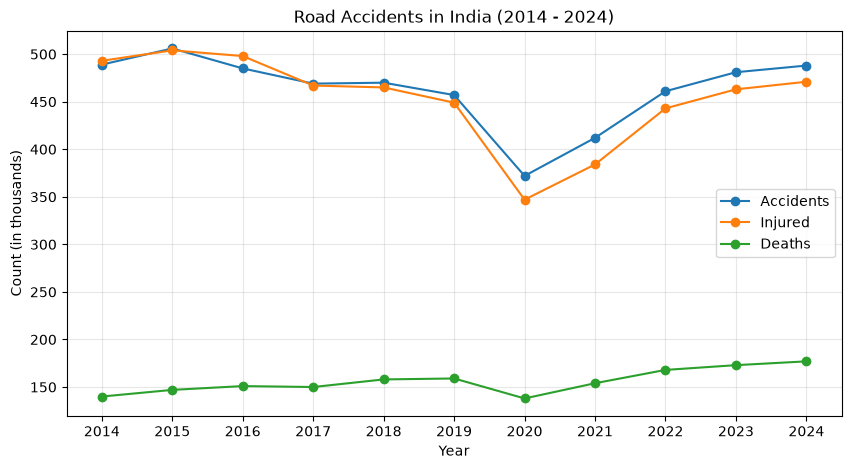

In [223]:
plt.figure(figsize=(10, 5))
plt.plot(density['Year'], density['Accidents_000'], marker='o', label='Accidents')
plt.plot(density['Year'], density['Injuries_000'], marker='o', label='Injured')
plt.plot(density['Year'], density['Deaths_000'], marker='o', label='Deaths')
plt.title('Road Accidents in India (2014 - 2024)')
plt.xlabel('Year')
plt.ylabel("Count (in thousands)")
plt.xticks(density['Year'])
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(fig_path + 'A2_accidents_deaths_trend_2014_2024.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

In [224]:
# death % change from 2014 to 2024
d2014 = density[density['Year'] == 2014]['Deaths_000'].values[0]
d2024 = density[density['Year'] == 2024]['Deaths_000'].values[0]
print("Deaths in 2014:", d2014, "thousand")
print("Deaths in 2024:", d2024, "thousand")
print("Increase:", round((d2024 - d2014) / d2014 * 100, 1), "%")

Deaths in 2014: 140.0 thousand
Deaths in 2024: 177.0 thousand
Increase: 26.4 %


**Observation:**
- Accidents were slowly going down from 2015 to 2019, then there is a big drop in **2020 because of the COVID lockdown**.
- After 2020, accidents increased again and in 2024 they are almost back to the old level (around 4.88 lakh).
- But **deaths are always going up** - from 1.40 lakh in 2014 to 1.77 lakh in 2024 (about **26% increase**), even in years when accidents went down. So accidents are becoming more deadly.

### A3. How many people die per 100 accidents (severity) each year

   Year  Accidents  Fatalities  Deaths per 100 Accidents
0  2020     372181      138383                     37.18
1  2021     412432      153972                     37.33
2  2022     461312      168491                     36.52
3  2023     480583      172890                     35.98
4  2024     487707      177175                     36.33


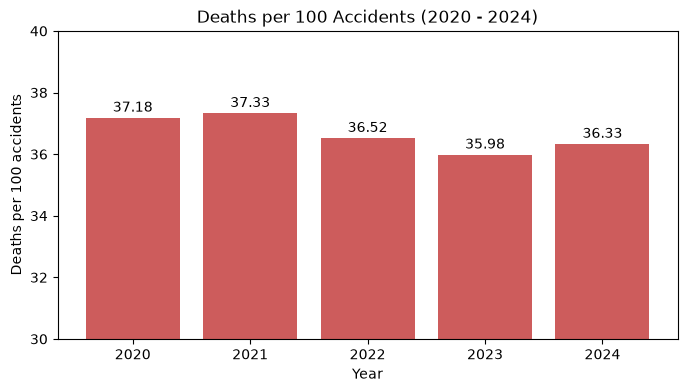

In [225]:
annual['Deaths per 100 Accidents'] = (annual['Fatalities'] / annual['Accidents'] * 100).round(2)
print(annual[['Year', 'Accidents', 'Fatalities', 'Deaths per 100 Accidents']])

plt.figure(figsize=(8, 4))
plt.bar(annual['Year'], annual['Deaths per 100 Accidents'], color='indianred')
plt.title('Deaths per 100 Accidents (2020 - 2024)')
plt.xlabel('Year')
plt.ylabel('Deaths per 100 accidents')
plt.ylim(30, 40)
for i in range(len(annual)):
    plt.text(annual['Year'][i], annual['Deaths per 100 Accidents'][i] + 0.2,
             annual['Deaths per 100 Accidents'][i], ha='center')
plt.savefig(fig_path + 'A3_deaths_per_100_accidents_yearly.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:** Around **36 - 37 people die in every 100 accidents** in India. This number has not improved much in 5 years.

### A4. Vehicles are increasing but is the death rate also increasing?

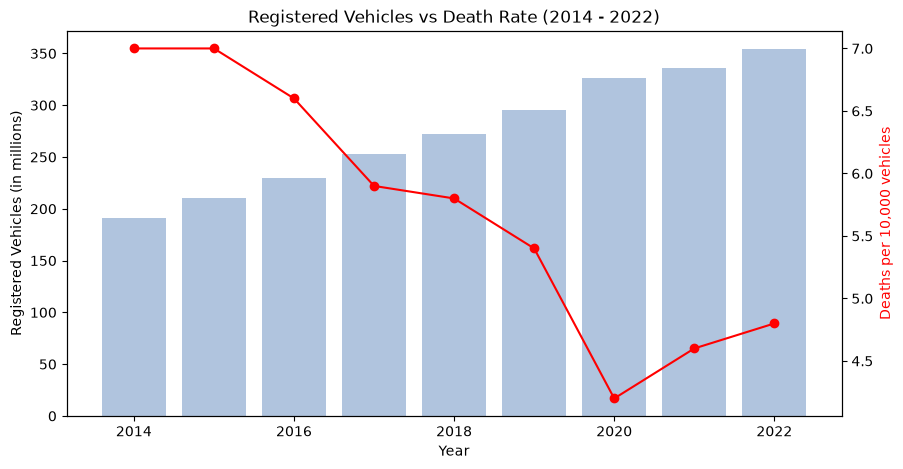

In [226]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(density_vehicles['Year'], density_vehicles['Vehicles_000'] / 1000, color='lightsteelblue', label='Registered Vehicles')
ax1.set_xlabel('Year')
ax1.set_ylabel('Registered Vehicles (in millions)')

ax2 = ax1.twinx()   # second y axis
ax2.plot(density_vehicles['Year'], density_vehicles['Death_rate_per_10k_vehicles'], color='red', marker='o', label='Death rate')
ax2.set_ylabel('Deaths per 10,000 vehicles', color='red')

plt.title('Registered Vehicles vs Death Rate (2014 - 2022)')
plt.savefig(fig_path + 'A4_vehicles_vs_death_rate.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:**
- Registered vehicles almost **doubled** (19 crore in 2014 to 35 crore in 2022).
- Deaths per 10,000 vehicles came down from 7.0 to 4.8, so roads are slightly safer *per vehicle*.
- But since the number of vehicles is increasing so fast, the **total deaths are still increasing**.

### A5. Top 10 states by road accidents and deaths in 2024

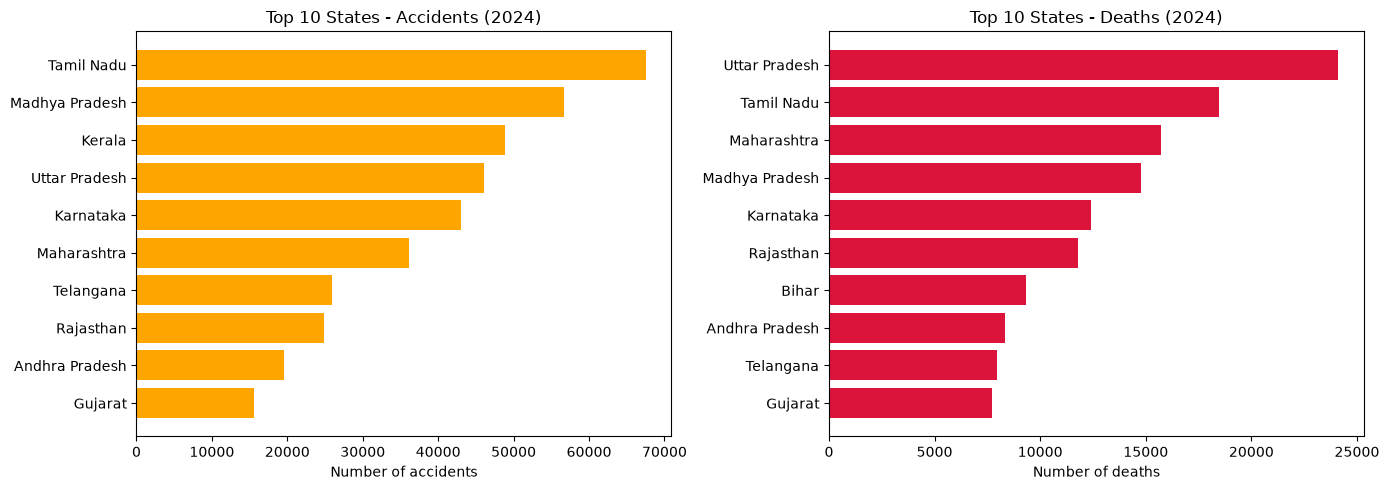

In [227]:
top10_acc = state_accidents.sort_values('2024 Accidents', ascending=False).head(10)
top10_killed = state_killed.sort_values('2024 Killed', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_acc['State'], top10_acc['2024 Accidents'], color='orange')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 States - Accidents (2024)')
axes[0].set_xlabel('Number of accidents')

axes[1].barh(top10_killed['State'], top10_killed['2024 Killed'], color='crimson')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 States - Deaths (2024)')
axes[1].set_xlabel('Number of deaths')

plt.tight_layout()
plt.savefig(fig_path + 'A5_top10_states_accidents_deaths.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

In [228]:
# what % of all india deaths come from top 5 states
total_killed_2024 = state_killed['2024 Killed'].sum()
top5_killed = top10_killed.head(5)['2024 Killed'].sum()
print("Top 5 states share of total deaths:", round(top5_killed / total_killed_2024 * 100, 1), "%")

Top 5 states share of total deaths: 48.2 %


**Observation:**
- **Tamil Nadu** has the highest number of accidents, but **Uttar Pradesh** has the highest number of deaths (24,118).
- **Kerala** is 3rd in accidents but it is not even in the top 10 for deaths.
- The **top 5 states (UP, Tamil Nadu, Maharashtra, Madhya Pradesh, Karnataka) give about 48% of all road deaths** in India.

### A6. Which states have the most severe accidents?

Number of accidents alone is not enough. A state may have fewer accidents but more people die in them.
So I am calculating **deaths per 100 accidents** for each state.

National average severity: 36.3


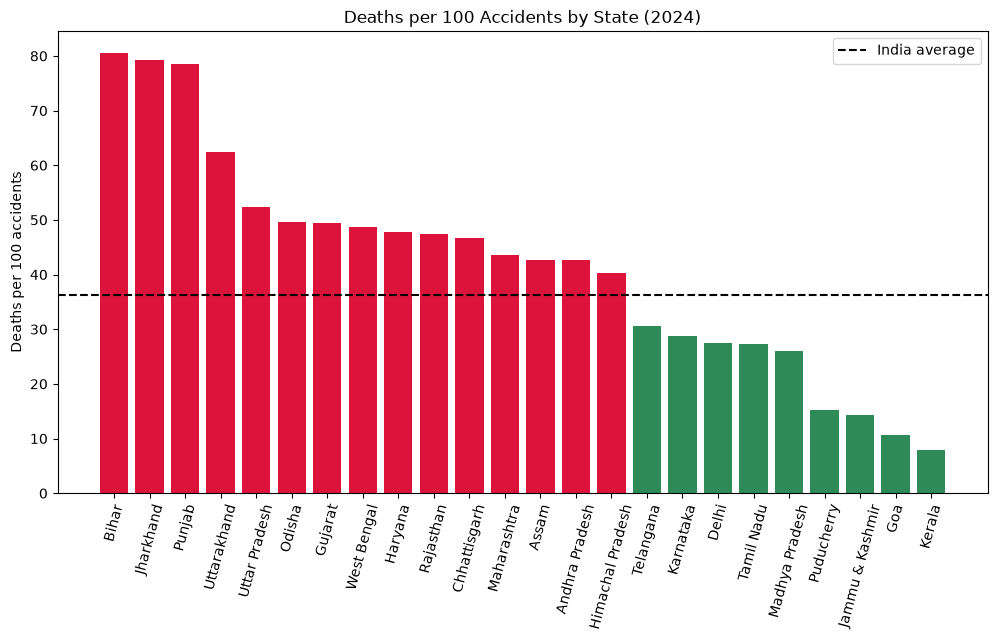

In [229]:
# joining the two state tables
states = pd.merge(state_accidents[['State', '2024 Accidents']],
                  state_killed[['State', '2024 Killed']], on='State')

# only taking states with at least 1000 accidents (small UTs give very odd values)
states = states[states['2024 Accidents'] >= 1000]

states['Severity'] = (states['2024 Killed'] / states['2024 Accidents'] * 100).round(1)
states = states.sort_values('Severity', ascending=False)

national_severity = round(total_killed_2024 / state_accidents['2024 Accidents'].sum() * 100, 1)
print("National average severity:", national_severity)

plt.figure(figsize=(12, 6))
colors = []
for s in states['Severity']:
    if s > national_severity:
        colors.append('crimson')
    else:
        colors.append('seagreen')
plt.bar(states['State'], states['Severity'], color=colors)
plt.axhline(national_severity, color='black', linestyle='--', label='India average')
plt.title('Deaths per 100 Accidents by State (2024)')
plt.ylabel('Deaths per 100 accidents')
plt.xticks(rotation=75)
plt.legend()
plt.savefig(fig_path + 'A6_state_severity_2024.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

In [230]:
print("Most severe 5 states:")
print(states.head(5))
print()
print("Least severe 5 states:")
print(states.tail(5))

Most severe 5 states:
            State  2024 Accidents  2024 Killed  Severity
3           Bihar           11610         9347      80.5
9       Jharkhand            5196         4114      79.2
19         Punjab            6063         4759      78.5
25    Uttarakhand            1747         1090      62.4
26  Uttar Pradesh           46052        24118      52.4

Least severe 5 states:
              State  2024 Accidents  2024 Killed  Severity
12   Madhya Pradesh           56669        14791      26.1
35       Puducherry            1431          218      15.2
32  Jammu & Kashmir            5808          831      14.3
5               Goa            2682          286      10.7
11           Kerala           48834         3880       7.9


**Observation:**
- In **Bihar, Jharkhand and Punjab, about 80 people die in every 100 accidents** - more than double the India average (36.3).
- **Kerala has only about 8 deaths per 100 accidents**, the lowest.
- One possible reason: in some states small accidents are not reported to police, so only serious accidents get counted. Better hospitals and faster ambulance service can also reduce deaths. So **severity is a better measure of risk than number of accidents**.

### A7. Accidents vs deaths - scatter plot and correlation

Correlation between accidents and deaths: 0.863


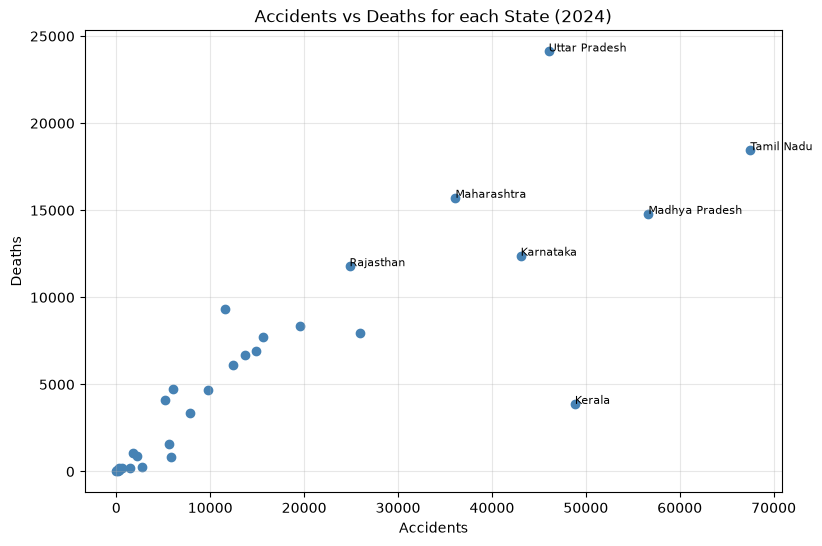

In [231]:
x = state_accidents['2024 Accidents']
y = state_killed['2024 Killed']

correlation = np.corrcoef(x, y)[0, 1]
print("Correlation between accidents and deaths:", round(correlation, 3))

plt.figure(figsize=(9, 6))
plt.scatter(x, y, color='steelblue')

# writing names of a few important states
for i in range(len(state_accidents)):
    if state_accidents['2024 Accidents'][i] > 30000 or state_killed['2024 Killed'][i] > 10000:
        plt.text(x[i], y[i], state_accidents['State'][i], fontsize=8)

plt.title('Accidents vs Deaths for each State (2024)')
plt.xlabel('Accidents')
plt.ylabel('Deaths')
plt.grid(alpha=0.3)
plt.savefig(fig_path + 'A7_accidents_vs_deaths_scatter.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:** Correlation is **0.86**, so states with more accidents usually have more deaths. But there are clear outliers - **Uttar Pradesh is far above** the line (very deadly) and **Kerala is far below** it (many accidents but few deaths).

### A8. Fastest growing states (2020 to 2024)

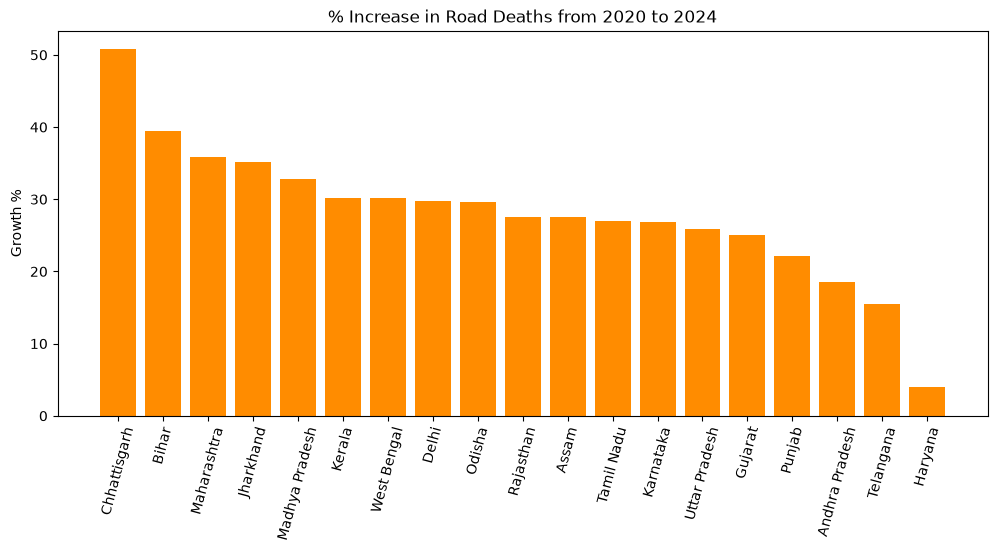

,State,2020 Killed,2024 Killed,Growth %
4,Chhattisgarh,4606,6945,50.8
3,Bihar,6699,9347,39.5
13,Maharashtra,11569,15715,35.8
9,Jharkhand,3044,4114,35.2
12,Madhya Pradesh,11141,14791,32.8


In [233]:
growth = state_killed[['State', '2020 Killed', '2024 Killed']].copy()
growth = growth[growth['2020 Killed'] >= 1000]     # ignoring very small states
growth['Growth %'] = ((growth['2024 Killed'] - growth['2020 Killed']) / growth['2020 Killed'] * 100).round(1)
growth = growth.sort_values('Growth %', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(growth['State'], growth['Growth %'], color='darkorange')
plt.title('% Increase in Road Deaths from 2020 to 2024')
plt.ylabel('Growth %')
plt.xticks(rotation=75)
plt.savefig(fig_path + 'A8_state_growth_2020_2024.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

growth.head(5)

**Observation:** **Chhattisgarh (+51%), Bihar (+40%) and Maharashtra (+36%)** have the fastest growth in road deaths from 2020 to 2024. (2020 was a lockdown year so some increase is expected in all states.)

### A9. Top 10 cities by road deaths (2024)

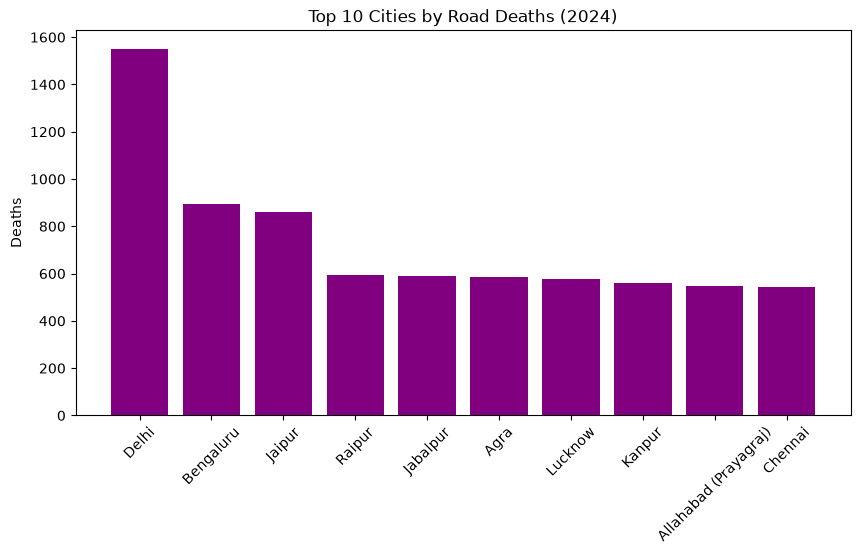

In [234]:
top_cities = city_violation.sort_values('Total', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_cities['City'], top_cities['Total'], color='purple')
plt.title('Top 10 Cities by Road Deaths (2024)')
plt.ylabel('Deaths')
plt.xticks(rotation=45)
plt.savefig(fig_path + 'A9_top10_cities_deaths.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:** **Delhi** has the most road deaths among cities (1,551), almost double of Bengaluru (894) and Jaipur (860).

### A10. India compared with other countries (2019)

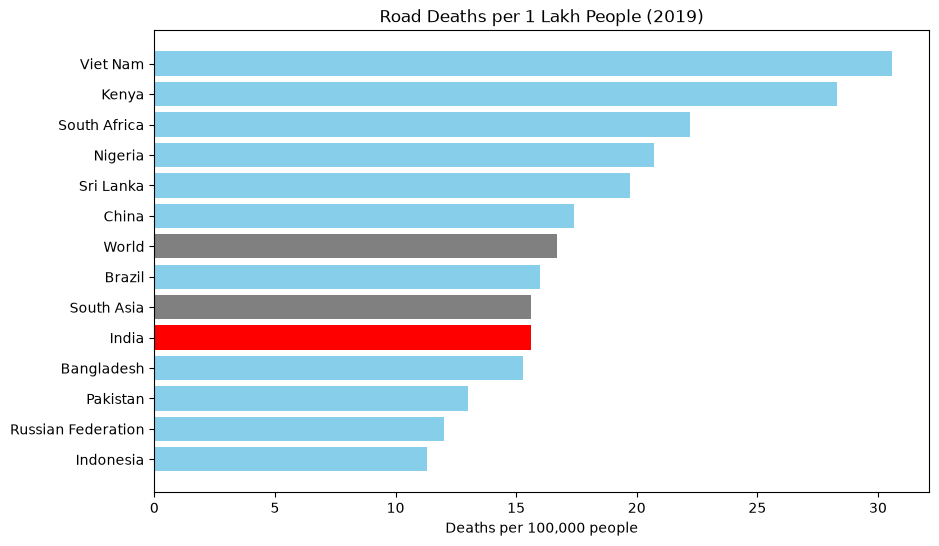

In [235]:
world_sorted = world_deaths.sort_values('Deaths_per_100k')

colors = []
for c in world_sorted['Country']:
    if c == 'India':
        colors.append('red')
    elif c in ['World', 'South Asia']:
        colors.append('gray')
    else:
        colors.append('skyblue')

plt.figure(figsize=(10, 6))
plt.barh(world_sorted['Country'], world_sorted['Deaths_per_100k'], color=colors)
plt.title('Road Deaths per 1 Lakh People (2019)')
plt.xlabel('Deaths per 100,000 people')
plt.savefig(fig_path + 'A10_india_vs_world.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:** India's death rate (15.6 per lakh people) is almost the same as the South Asia average and slightly below the world average (16.7). But because India has a huge population, the **total number of deaths is very high**.

## Part B : Causes

### B1. Traffic violations behind accidents (2024)

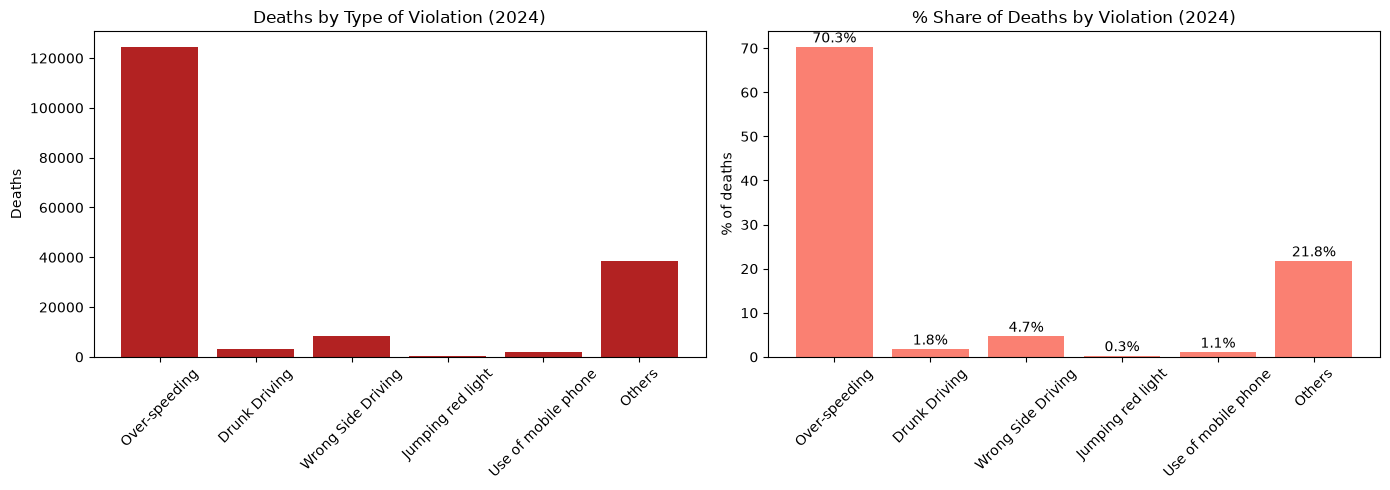

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(violation['Category'], violation['2024-Killed'], color='firebrick')
axes[0].set_title('Deaths by Type of Violation (2024)')
axes[0].set_ylabel('Deaths')
axes[0].tick_params(axis='x', rotation=45)

# pie chart labels were overlapping for small values, so i used a bar chart of % share
violation['Share %'] = (violation['2024-Killed'] / violation['2024-Killed'].sum() * 100).round(1)
axes[1].bar(violation['Category'], violation['Share %'], color='salmon')
axes[1].set_title('% Share of Deaths by Violation (2024)')
axes[1].set_ylabel('% of deaths')
axes[1].tick_params(axis='x', rotation=45)
for i in range(len(violation)):
    axes[1].text(i, violation['Share %'][i] + 1, str(violation['Share %'][i]) + '%', ha='center')

plt.tight_layout()
plt.savefig(fig_path + 'B1_violation_deaths.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

In [237]:
# deaths per 100 accidents for each violation
violation['Severity'] = (violation['2024-Killed'] / violation['2024-Accidents'] * 100).round(1)
violation[['Category', '2024-Accidents', '2024-Killed', 'Severity']].sort_values('Severity', ascending=False)

,Category,2024-Accidents,2024-Killed,Severity
4,Use of mobile phone,4935,2002,40.6
1,Drunk Driving,8270,3204,38.7
2,Wrong Side Driving,22530,8327,37.0
5,Others,105389,38592,36.6
0,Over-speeding,345024,124522,36.1
3,Jumping red light,1559,528,33.9


**Observation:**
- **Over-speeding causes about 70% of all road deaths** (1.24 lakh deaths in 2024). This is the biggest cause by far.
- But per accident, **using mobile phone (40.6) and drunk driving (38.7)** are the most deadly.

### B2. Over-speeding over the years (2008 - 2016)

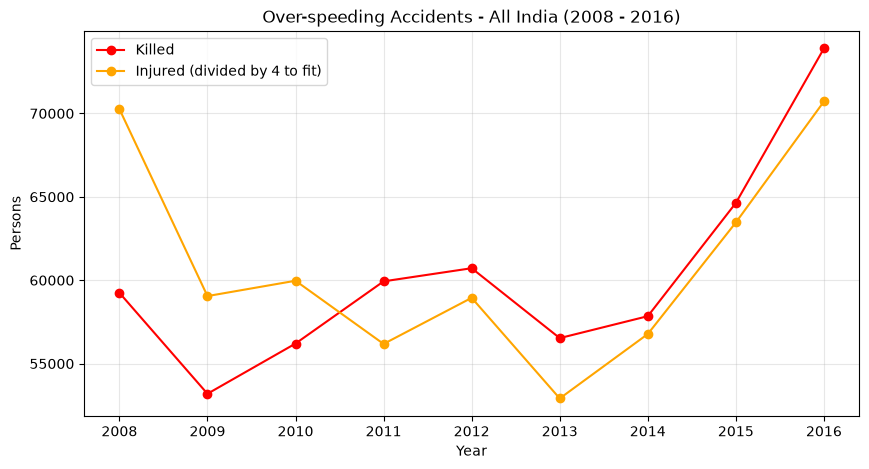

Killed due to over speeding: 2008 = 59246 , 2016 = 73896


In [238]:
speed_trend = speed_killed_india[year_cols].values[0]
injured_trend = speed_injured_india[year_cols].values[0]
years = [int(y) for y in year_cols]

plt.figure(figsize=(10, 5))
plt.plot(years, speed_trend, marker='o', color='red', label='Killed')
plt.plot(years, injured_trend / 4, marker='o', color='orange', label='Injured (divided by 4 to fit)')
plt.title('Over-speeding Accidents - All India (2008 - 2016)')
plt.xlabel('Year')
plt.ylabel('Persons')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(fig_path + 'B2_overspeeding_trend_2008_2016.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

print("Killed due to over speeding: 2008 =", speed_trend[0], ", 2016 =", speed_trend[-1])

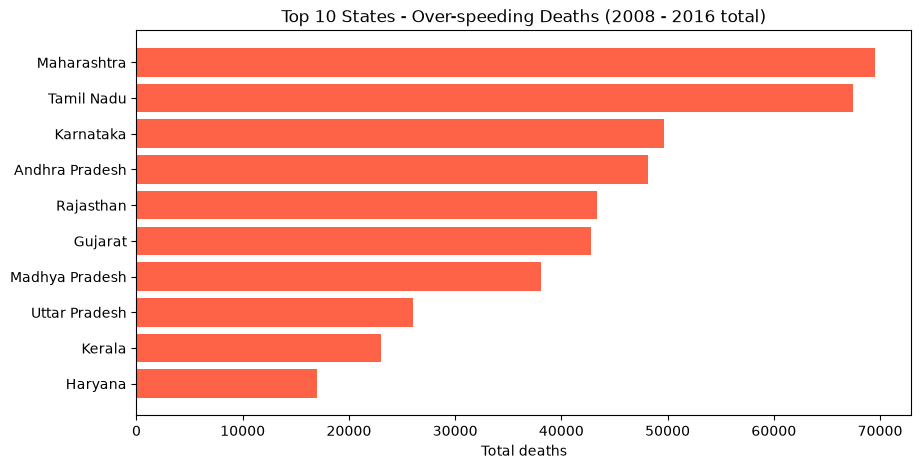

In [239]:
# top 10 states for over-speeding deaths (total 2008-2016)
speed_killed['Total'] = speed_killed[year_cols].sum(axis=1)
top_speed = speed_killed.sort_values('Total', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_speed['States/UTs'], top_speed['Total'], color='tomato')
plt.gca().invert_yaxis()
plt.title('Top 10 States - Over-speeding Deaths (2008 - 2016 total)')
plt.xlabel('Total deaths')
plt.savefig(fig_path + 'B2_top10_states_overspeeding.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:**
- Deaths due to over-speeding increased from **59,246 in 2008 to 73,896 in 2016** (about 25% increase).
- **Maharashtra and Tamil Nadu** had the most over-speeding deaths in this period, followed by Karnataka and Andhra Pradesh.

### B3. Type of collision (2024)

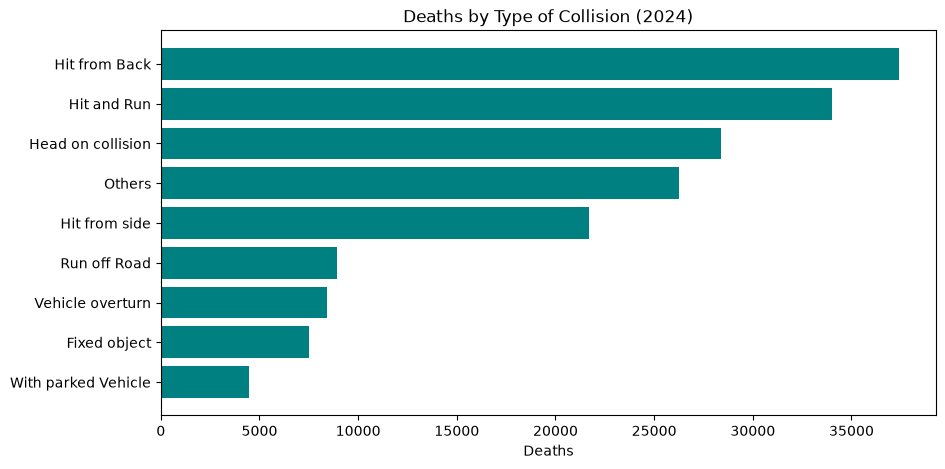

,Type of collision,2024-Accidents,2024-Killed,Severity
0,Hit and Run,68584,34030,49.6
6,Vehicle overturn,17296,8419,48.7
4,Run off Road,19082,8917,46.7
5,Fixed object,16246,7521,46.3
1,With parked Vehicle,11198,4486,40.1
7,Head on collision,84429,28400,33.6
8,Others,79853,26282,32.9
2,Hit from Back,113907,37404,32.8
3,Hit from side,77112,21716,28.2


In [240]:
collision_sorted = collision.sort_values('2024-Killed', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(collision_sorted['Type of collision'], collision_sorted['2024-Killed'], color='teal')
plt.title('Deaths by Type of Collision (2024)')
plt.xlabel('Deaths')
plt.savefig(fig_path + 'B3_collision_type_deaths.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

collision['Severity'] = (collision['2024-Killed'] / collision['2024-Accidents'] * 100).round(1)
collision[['Type of collision', '2024-Accidents', '2024-Killed', 'Severity']].sort_values('Severity', ascending=False)

**Observation:**
- **Hit from back** causes the most deaths (37,404), followed by **Hit and Run** (34,030).
- **Hit and Run is the most deadly** - almost **50 deaths per 100 accidents** (because the victim is left on the road without help). Vehicle overturn and running off the road are also very deadly.

### B4. Road conditions / road features (2018)

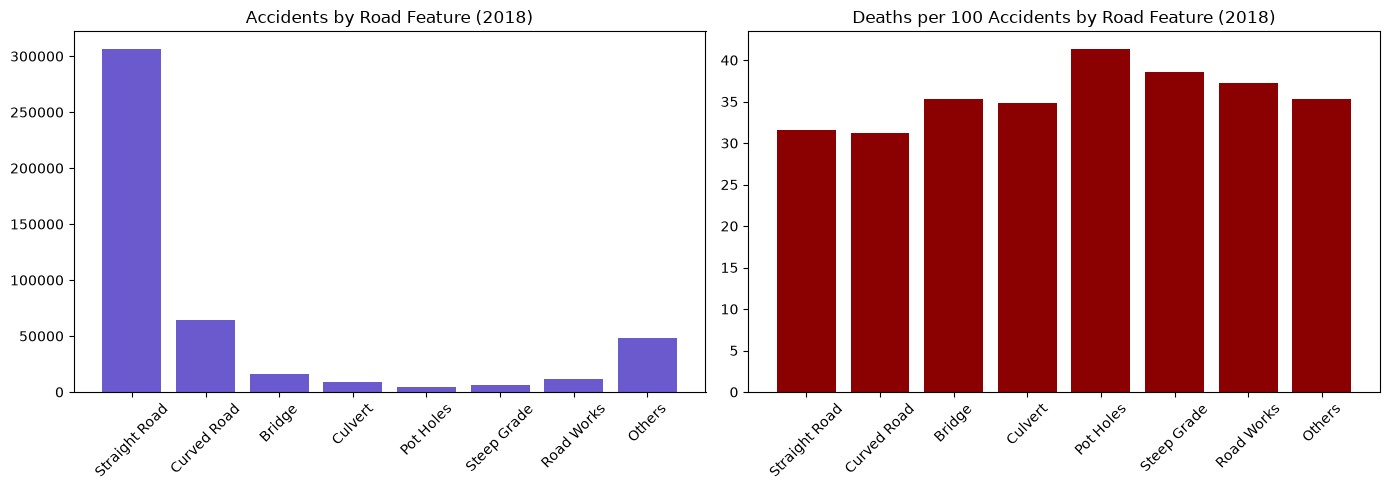

,Road Feature,Accidents,Killed,Severity
4,Pot Holes,4869,2015,41.4
5,Steep Grade,6305,2433,38.6
6,Road Works,11539,4288,37.2
2,Bridge,16125,5693,35.3
7,Others,48068,16969,35.3
3,Culvert,9183,3192,34.8
0,Straight Road,306855,96831,31.6
1,Curved Road,64100,19996,31.2


In [241]:
feature_summary['Severity'] = (feature_summary['Killed'] / feature_summary['Accidents'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(feature_summary['Road Feature'], feature_summary['Accidents'], color='slateblue')
axes[0].set_title('Accidents by Road Feature (2018)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(feature_summary['Road Feature'], feature_summary['Severity'], color='darkred')
axes[1].set_title('Deaths per 100 Accidents by Road Feature (2018)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(fig_path + 'B4_road_features.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

feature_summary.sort_values('Severity', ascending=False)

**Observation:**
- Most accidents happen on **straight roads** - maybe because people drive fast on them.
- But **potholes are the most deadly road condition (41 deaths per 100 accidents)**, followed by steep grade and road works. So bad road condition is a high-risk factor.

### B5. Violations in the top cities (stacked bar)

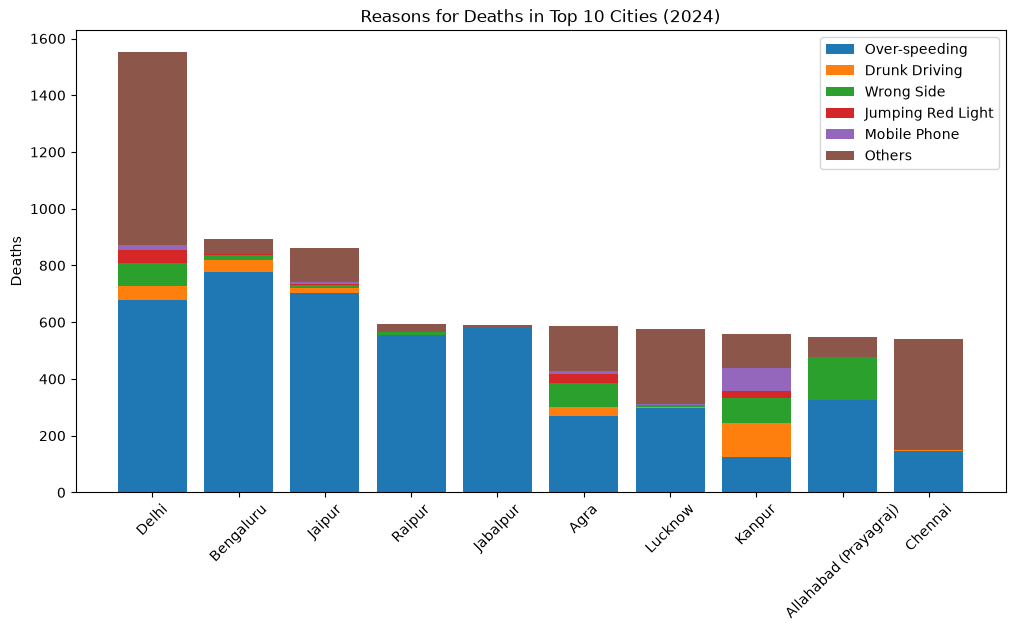

In [242]:
reasons = ['Over-speeding', 'Drunk Driving', 'Wrong Side', 'Jumping Red Light', 'Mobile Phone', 'Others']

plt.figure(figsize=(12, 6))
bottom = np.zeros(len(top_cities))
for r in reasons:
    plt.bar(top_cities['City'], top_cities[r], bottom=bottom, label=r)
    bottom = bottom + top_cities[r].values

plt.title('Reasons for Deaths in Top 10 Cities (2024)')
plt.ylabel('Deaths')
plt.xticks(rotation=45)
plt.legend()
plt.savefig(fig_path + 'B5_city_violation_stacked.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:**
- In **Bengaluru, Jaipur, Raipur and Jabalpur almost all deaths are due to over-speeding**.
- **Kanpur** has a high share of drunk driving and mobile phone use, and **Prayagraj** has many wrong side driving deaths.
- In Delhi and Chennai a big part is "Others", which means the reason was not recorded properly.

## Part C : High-Risk Factors

### C1. Which road users die the most (2024)

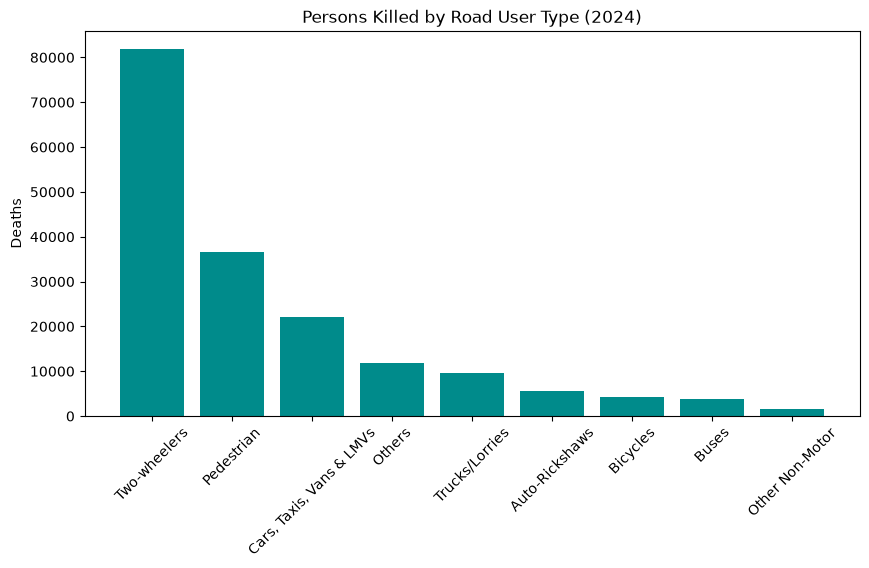

,Road-user category,Persons killed 2023,Persons killed 2024,% Change 2024 over 2023,Share %
2,Two-wheelers,77539,81780,5.5,46.2
0,Pedestrian,35221,36526,3.7,20.6
4,"Cars, Taxis, Vans & LMVs",21496,21988,2.3,12.4
8,Others,11738,11890,1.3,6.7
5,Trucks/Lorries,10066,9687,-3.8,5.5
3,Auto-Rickshaws,6308,5659,-10.3,3.2
1,Bicycles,4560,4161,-8.8,2.3
6,Buses,3956,3855,-2.6,2.2
7,Other Non-Motor,2006,1629,-18.8,0.9


In [243]:
road_user_sorted = road_user.sort_values('Persons killed 2024', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(road_user_sorted['Road-user category'], road_user_sorted['Persons killed 2024'], color='darkcyan')
plt.title('Persons Killed by Road User Type (2024)')
plt.ylabel('Deaths')
plt.xticks(rotation=45)
plt.savefig(fig_path + 'C1_road_user_deaths.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

total = road_user['Persons killed 2024'].sum()
road_user['Share %'] = (road_user['Persons killed 2024'] / total * 100).round(1)
road_user.sort_values('Share %', ascending=False)

**Observation:**
- **Two-wheeler riders are 46% of all road deaths** (81,780 people in 2024).
- **Pedestrians are the second highest (20.6%)**.
- So two-wheeler riders and pedestrians together are about **two-thirds of all deaths**. These are the most vulnerable road users.

### C2. Who hits whom? (Victim vehicle vs Crime vehicle - 2024)

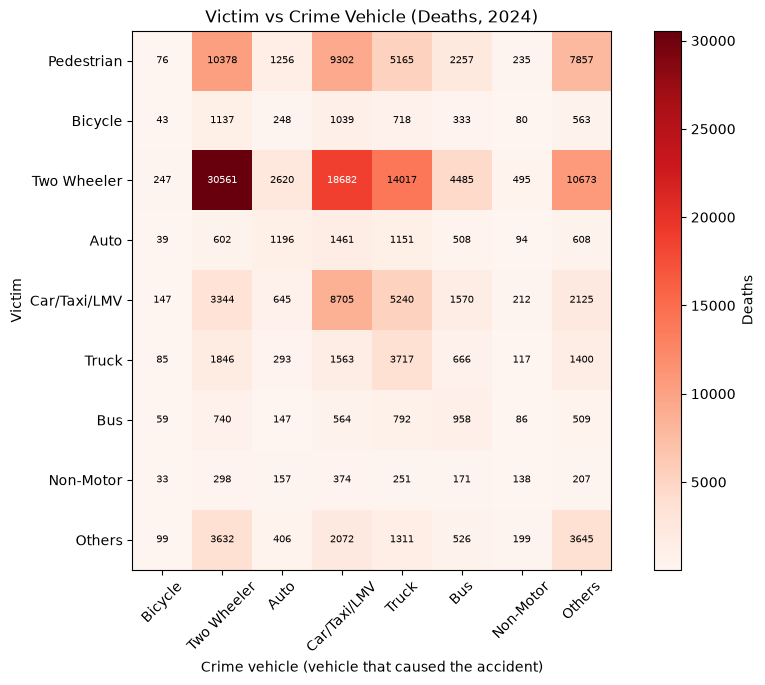

In [244]:
matrix = victim_vehicle.drop(columns=['Victim', 'Total'])
values = matrix.values

plt.figure(figsize=(11, 7))
plt.imshow(values, cmap='Reds')
plt.colorbar(label='Deaths')

plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=45)
plt.yticks(range(len(victim_vehicle)), victim_vehicle['Victim'])
plt.xlabel('Crime vehicle (vehicle that caused the accident)')
plt.ylabel('Victim')
plt.title('Victim vs Crime Vehicle (Deaths, 2024)')

# writing the numbers inside each box
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        if values[i, j] > 15000:
            text_color = 'white'     # white text on dark boxes
        else:
            text_color = 'black'
        plt.text(j, i, int(values[i, j]), ha='center', va='center', fontsize=7, color=text_color)

plt.savefig(fig_path + 'C2_victim_vs_crime_vehicle.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:**
- The biggest number is **two-wheeler hitting two-wheeler** (30,561 deaths).
- Two-wheeler riders are also killed a lot by **cars (18,682) and trucks (14,017)**.
- Pedestrians are mostly killed by **two-wheelers and cars**.

### C3. Not wearing helmet / seat belt (2024)

Deaths without helmet   : 54122
Deaths without seat belt: 14466
% of two wheeler deaths without helmet: 66.2 %


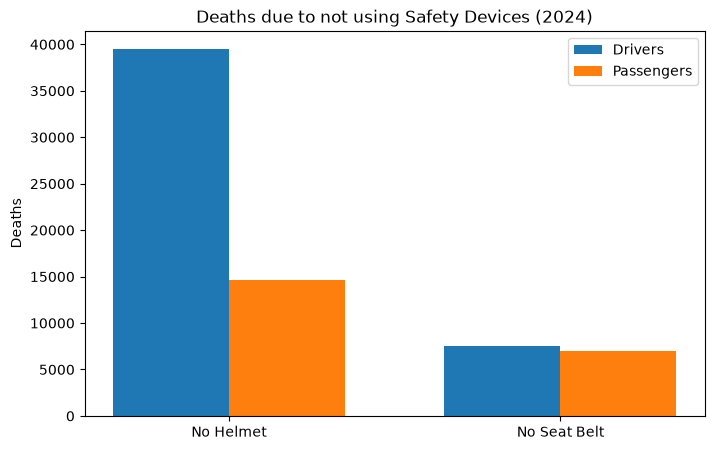

In [245]:
helmet_killed = safety_device['No Helmet - Killed'].sum()
seatbelt_killed = safety_device['No Seat belt - killed'].sum()
two_wheeler_deaths = road_user[road_user['Road-user category'] == 'Two-wheelers']['Persons killed 2024'].values[0]

print("Deaths without helmet   :", helmet_killed)
print("Deaths without seat belt:", seatbelt_killed)
print("% of two wheeler deaths without helmet:", round(helmet_killed / two_wheeler_deaths * 100, 1), "%")

x = np.arange(2)
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, [safety_device['No Helmet - Killed'][0], safety_device['No Seat belt - killed'][0]], width, label='Drivers')
plt.bar(x + width/2, [safety_device['No Helmet - Killed'][1], safety_device['No Seat belt - killed'][1]], width, label='Passengers')
plt.xticks(x, ['No Helmet', 'No Seat Belt'])
plt.ylabel('Deaths')
plt.title('Deaths due to not using Safety Devices (2024)')
plt.legend()
plt.savefig(fig_path + 'C3_helmet_seatbelt.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

**Observation:**
- **54,122 people died because they were not wearing a helmet**. That is around **66% of all two-wheeler deaths**.
- 14,466 people died without a seat belt.
- Most helmet deaths are drivers (73%), but passengers also do not wear helmets.

### C4. Age group and gender of victims (2018)

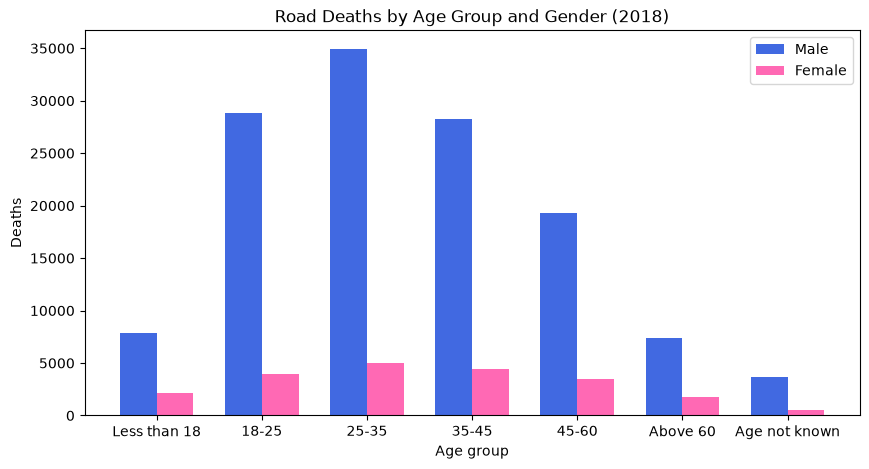

Male share  : 86.0 %
Female share: 14.0 %
Age 18-45 share of deaths: 69.6 %


In [246]:
x = np.arange(len(age_gender))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, age_gender['2018 - Male'], width, label='Male', color='royalblue')
plt.bar(x + width/2, age_gender['2018 - Female'], width, label='Female', color='hotpink')
plt.xticks(x, age_gender['Age-Group'])
plt.title('Road Deaths by Age Group and Gender (2018)')
plt.xlabel('Age group')
plt.ylabel('Deaths')
plt.legend()
plt.savefig(fig_path + 'C4_age_gender.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

male = age_gender['2018 - Male'].sum()
female = age_gender['2018 - Female'].sum()
print("Male share  :", round(male / (male + female) * 100, 1), "%")
print("Female share:", round(female / (male + female) * 100, 1), "%")

age_18_45 = age_gender[age_gender['Age-Group'].isin(['18-25', '25-35', '35-45'])]
young = age_18_45['2018 - Male'].sum() + age_18_45['2018 - Female'].sum()
print("Age 18-45 share of deaths:", round(young / (male + female) * 100, 1), "%")

**Observation:**
- **86% of the people killed are male**.
- **About 70% of deaths are in the 18 - 45 age group**, and 25 - 35 is the highest. These are young working people, so it is a big loss for families and the economy.

### C5. Driving licence of drivers involved in accidents (2020 - 2024)

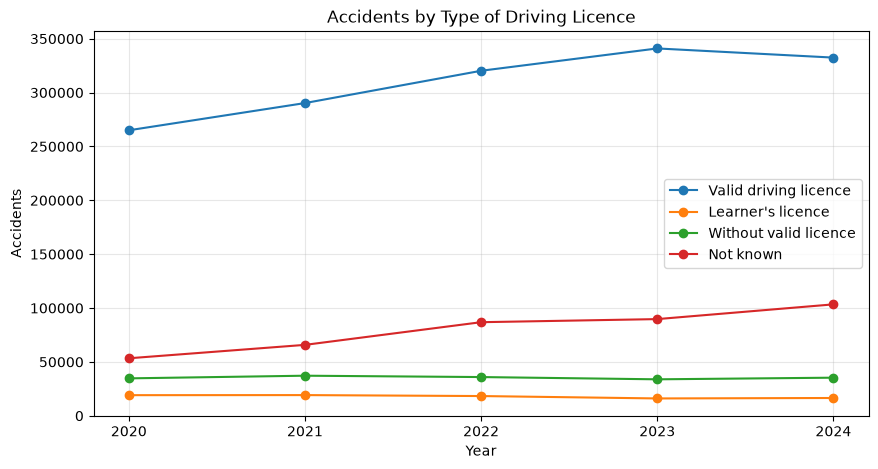

,Type of license,2020,2021,2022,2023,2024,%Change 2023 to 2024
0,Valid driving licence,264991.0,290261.0,320235.0,340960.0,332462.0,-3.0
1,Learner's licence,19117.0,19184.0,18298.0,16074.0,16494.0,2.6
2,Without valid licence,34716.0,37182.0,35925.0,33827.0,35347.0,4.5
3,Not known,53357.0,65805.0,86854.0,89722.0,103404.0,15.0


In [247]:
lic_years = ['2020', '2021', '2022', '2023', '2024']

plt.figure(figsize=(10, 5))
for i in range(len(license_type)):
    plt.plot(lic_years, license_type.loc[i, lic_years], marker='o', label=license_type['Type of license'][i])
plt.title('Accidents by Type of Driving Licence')
plt.xlabel('Year')
plt.ylabel('Accidents')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(fig_path + 'C5_license_type.png', dpi=300, bbox_inches='tight')   # saving the figure
plt.show()

license_type

**Observation:**
- Most accidents (about 68%) are by drivers **with a valid licence**, so having a licence does not mean safe driving.
- The **"Not known" category is increasing every year** (53k to 1 lakh), which shows a problem in how data is recorded.

### Checking all the saved figures

In [248]:
saved_figures = sorted(os.listdir(fig_path))

print("Total figures saved:", len(saved_figures))
print()
for f in saved_figures:
    print("  ", f)

Total figures saved: 21

   A10_india_vs_world.png
   A2_accidents_deaths_trend_2014_2024.png
   A3_deaths_per_100_accidents_yearly.png
   A4_vehicles_vs_death_rate.png
   A5_top10_states_accidents_deaths.png
   A6_state_severity_2024.png
   A7_accidents_vs_deaths_heatmap.png
   A7_accidents_vs_deaths_scatter.png
   A8_state_growth_2020_2024.png
   A9_top10_cities_deaths.png
   B1_violation_deaths.png
   B2_overspeeding_trend_2008_2016.png
   B2_top10_states_overspeeding.png
   B3_collision_type_deaths.png
   B4_road_features.png
   B5_city_violation_stacked.png
   C1_road_user_deaths.png
   C2_victim_vs_crime_vehicle.png
   C3_helmet_seatbelt.png
   C4_age_gender.png
   C5_license_type.png


# Step 6 : Summary of EDA

**Patterns**
1. Road deaths increased by about **26% from 2014 to 2024**, even though accidents did not increase much.
2. About **36 people die in every 100 accidents** in India.
3. **5 states give almost half of all deaths** - UP, Tamil Nadu, Maharashtra, MP and Karnataka.
4. **Bihar, Jharkhand and Punjab** have the most deadly accidents (around 80 deaths per 100), while **Kerala** has the least (about 8).

**Causes**
1. **Over-speeding** is the biggest cause (about 70% of deaths).
2. **Mobile phone use and drunk driving** are the most deadly per accident.
3. **Hit and run** and **vehicle overturn** have the highest death rate among collision types.
4. **Potholes** are the most deadly road condition.

**High-Risk Factors**
1. **Two-wheeler riders (46%) and pedestrians (21%)** are the most at risk.
2. **Not wearing a helmet** is linked to about 66% of two-wheeler deaths.
3. **Young males (18 - 45 years)** are the most affected group.

**Data limitations:** state data is aggregated (no accident level records), some years have missing values, different files are from different years (2008 - 2024), and many cases are recorded as "Others" or "Not known".

**Next step :** Feature engineering and applying Machine Learning models (clustering states by risk level and predicting severity).